# DTSC691 - Machine Learning Project by Diana Ogendi


# Graph Based and Contrastive Learning Fraud Detection on Financial Data

---


## Model Training

In traditional Machine Learning, each row in your train data is treated as an independent event. The model doesn't know that Transaction A and Transaction B were made by the same person unless it looks at a specific column.
In a Graph Neural Network (GNN), we turn those rows into "Nodes" and draw "Edges" (lines) between them. This allows the model to "talk" to neighboring transactions. If Transaction A is suspicious, it can "warn" Transaction B through the edge.


**Understanding the "Data" Object**
In PyTorch Geometric (the industry standard for GNNs), we don't use DataFrames. We use a Data Object. Think of it as a suitcase that holds three specific things:
* x (Node Features): Your train columns (Amount, Time, etc.).
* edge_index (The Map): A list showing which nodes are connected.
* y (The Label): Is it fraud (1) or not (0)?

In [1]:
# Essential Imports for Project

# Core
import os, gc, time, warnings
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Graph
import networkx as nx
import scipy.sparse as sp

# PyTorch + PyG
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader, NeighborLoader
from torch_geometric.nn import SAGEConv

# Contrastive
from torch.nn import CosineSimilarity

# Baselines
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
import xgboost as xgb

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

In [2]:
# Load Clean Train and Test 
train = pd.read_parquet("train_clean_final.parquet")
test = pd.read_parquet("test_clean_final.parquet")

# Quick Verification for dimensions and nulls
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"Total Nulls in Train: {train.isnull().sum().sum()}")
print(f"Total Nulls in Test: {test.isnull().sum().sum()}")

Train Shape: (590540, 437)
Test Shape: (506691, 436)
Total Nulls in Train: 0
Total Nulls in Test: 0


First, we need to make sure our "Category" columns (like DeviceInfo) are converted into numbers, because GNNs (which are Neural Networks) only understand math, not strings.

In [3]:
# Check for any remaining non-numeric columns
non_numeric = train.select_dtypes(exclude=["number"]).columns
print("Columns that need encoding:", non_numeric)

Columns that need encoding: Index(['ProductCD', 'P_emaildomain', 'R_emaildomain', 'id_30', 'id_31',
       'DeviceInfo'],
      dtype='object')


ProductCD is a small cardinality category which will benefit from one-hot encoding without risk of exploding dimensionality.

In [4]:
# Create the label 
tar_var = train["isFraud"].copy()

# One-hot encode ProductCD
train = pd.get_dummies(train, columns=["ProductCD"], prefix="ProductCD")
test = pd.get_dummies(test, columns=["ProductCD"], prefix="ProductCD")

# Ensure both have the same columns in the same order
# (If a category is missing in one, it adds a column of 0s)
train, test = train.align(test, join="inner", axis=1)

# Add back the target to train (align removes it since it's not in test)
train["isFraud"] = tar_var 

print(f"New columns after One-Hot: {[c for c in train.columns if 'ProductCD' in c]}")

New columns after One-Hot: ['ProductCD_C', 'ProductCD_H', 'ProductCD_R', 'ProductCD_S', 'ProductCD_W']


In a GNN, an Embedding is like a "personality profile" for a category. Instead of P_emaildomain being just a number like 42, the model gives it a small vector (e.g., 8 numbers). During training, the GNN adjusts these 8 numbers so that "gmail.com" and "icloud.com" might end up with similar vectors if they behave similarly in fraud patterns.

In [5]:
# Create a list of categories + DeviceType
cat_cols = ["P_emaildomain", "R_emaildomain", "id_30", "id_31", "DeviceInfo", "DeviceType"]

for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    codes, uniques = pd.factorize(combined)
    
    # Identify the "unknown" index (which is just the next available number)
    unknown_val = len(uniques)
    
    # Map the codes back
    train_codes = codes[:len(train)]
    test_codes = codes[len(train):]
    
    # Since pandas uses -1 for nothing, replace the -1s with a unknown category
    train[col] = pd.Series(train_codes).replace(-1, unknown_val).values
    test[col] = pd.Series(test_codes).replace(-1, unknown_val).values
    
    print(f"Encoded {col}: {len(uniques)} classes + 1 unknown category.")

Encoded P_emaildomain: 10 classes + 1 unknown category.
Encoded R_emaildomain: 10 classes + 1 unknown category.
Encoded id_30: 6 classes + 1 unknown category.
Encoded id_31: 13 classes + 1 unknown category.
Encoded DeviceInfo: 11 classes + 1 unknown category.
Encoded DeviceType: 3 classes + 1 unknown category.


I will run a logistic regression as a vital sanity check to ensure our underlying node features are clean and informative before introducing the complexity of a graph structure. This establishes a performance floor, allowing us to isolate whether poor results stem from basic data quality issues or the GNN’s architecture. By comparing the two, we can quantify exactly how much value the network topology adds over simple independent feature analysis.

In [6]:
# Baseline Logistic Regression Model
cat_cols = ["P_emaildomain", "R_emaildomain", "id_30", "id_31", "DeviceInfo", "DeviceType"]
numeric_features = [col for col in train.columns if col not in cat_cols and col != "isFraud"]

X = train[numeric_features + cat_cols].fillna(0)
y = train["isFraud"]

# Scale numeric features only
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

# Train logistic regression
clf = LogisticRegression(max_iter=200, class_weight="balanced")
clf.fit(X_scaled, y)

# Predict
probs = clf.predict_proba(X_scaled)[:, 1]
auc = roc_auc_score(y, probs)

print("Logistic Regression AUC:", auc)

Logistic Regression AUC: 0.873767799777529


The **FraudSAGE** model below combines traditional numeric transaction features with learned embeddings for key categorical attributes, allowing the GNN to capture both feature‑level signals and relational structure in the fraud graph. 
Each categorical field—such as email domains, device information, and OS/browser identifiers—is first integer‑encoded and then mapped into a compact, trainable embedding vector, enabling the model to learn semantic relationships between categories rather than treating them as arbitrary integers or sparse one‑hot vectors. 
These embeddings are concatenated with normalized numeric features and passed through two **GraphSAGE** message‑passing layers, each followed by **BatchNorm** to stabilize training and **dropout** to reduce overfitting. The GNN layers propagate information across connected transactions, allowing the model to detect fraud patterns that emerge only when viewing transactions in context. A final linear layer produces logits for the two fraud classes. 
Overall, this architecture blends dense learned representations with graph structure, giving the model the ability to reason about both individual transaction attributes and their relationships within the broader network.

In [7]:
class FraudSAGE(nn.Module):
    def __init__(self, num_numeric_features, sizes):
        super().__init__()

        # Create the Embedding Tables
        # We give each category 4 or 8 dimensions (numbers) to represent itself
        self.emb_p = nn.Embedding(sizes["P_emaildomain"], 8)
        self.emb_r = nn.Embedding(sizes["R_emaildomain"], 8)
        self.emb_id30 = nn.Embedding(sizes["id_30"], 4)
        self.emb_id31 = nn.Embedding(sizes["id_31"], 8)
        self.emb_dev = nn.Embedding(sizes["DeviceInfo"], 8)
        self.emb_dev_type = nn.Embedding(sizes["DeviceType"], 2) 

        total_emb_dim = 8 + 8 + 4 + 8 + 8 + 2

        # GNN Layers + Batch Normalization
        self.conv1 = SAGEConv(num_numeric_features + total_emb_dim, 64)
        self.bn1 = nn.BatchNorm1d(64) 
        
        self.conv2 = SAGEConv(64, 32)
        self.bn2 = nn.BatchNorm1d(32)

        self.out = nn.Linear(32, 2)

    def forward(self, x_numeric, x_cat, edge_index):
        # Embedding Lookup
        e_p = self.emb_p(x_cat[:, 0])
        e_r = self.emb_r(x_cat[:, 1])
        e_30 = self.emb_id30(x_cat[:, 2])
        e_31 = self.emb_id31(x_cat[:, 3])
        e_dev = self.emb_dev(x_cat[:, 4])
        e_dev_type = self.emb_dev_type(x_cat[:, 5])

        # Concatenate everything together
        x = torch.cat([x_numeric, e_p, e_r, e_30, e_31, e_dev, e_dev_type], dim=1)

        # Message Passing with BN and Dropout
        x = self.conv1(x, edge_index)
        x = self.bn1(x).relu()
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x).relu()
        
        # Final Prediction
        return self.out(x)

We used card1 to build the first graph because in the IEEE-CIS Fraud dataset, card1 is a proxy for the physical credit card. It is the most stable identity-like feature in the dataset, creating meaningful transaction clusters that allow the GNN to learn behavioral patterns and detect fraud propagation across related transactions.

I created an edge function uses a star‑graph pattern because it:
* Avoids quadratic blow‑up
* Preserves identity structure
* Is efficient for large datasets

In [6]:
def create_edges(df):
    # Group by the 'Identity' column (card1)
    # This finds all rows that share the same credit card
    grouped = df.groupby("card1").indices
    
    source_nodes = []
    target_nodes = []
    
    for card_id, indices in grouped.items():
        # If a card has more than one transaction, connect them
        if len(indices) > 1:
            # We create edges between all transactions in the group
            # For simplicity, we'll connect the first transaction to all others
            first_idx = indices[0]
            for other_idx in indices[1:]:
                source_nodes.append(first_idx)
                target_nodes.append(other_idx)
                
                # GNN edges are usually directed; add the reverse for undirected
                source_nodes.append(other_idx)
                target_nodes.append(first_idx)
    
    # Convert to a LongTensor [2, Num_Edges]
    edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
    return edge_index

# Execute
train_edge_index = create_edges(train)

print(f"Created {train_edge_index.shape[1]} edges based on shared card1 values.")

Created 1178570 edges based on shared card1 values.


To prepare the graph data for the GNN, we have to separate numeric and categorical features, scaling the numeric columns, and converting everything into PyTorch tensors. Categorical variables are kept as integer IDs for embedding layers, while numeric features are standardized for stable training. Finally, all components, features, labels, and edges are bundled into a PyG Data object that represents the full transaction graph the model will learn from.

In [ ]:
# Define categorical columns
cat_cols = ["P_emaildomain", "R_emaildomain", "id_30", "id_31", "DeviceInfo", "DeviceType"]

# Identify numeric features (everything else)
numeric_features = [
    col for col in train.columns 
    if col not in cat_cols and col != "isFraud"
]
# Scale numeric features
scaler = StandardScaler()
train[numeric_features] = scaler.fit_transform(train[numeric_features])

# Convert to tensors
x_numeric = torch.tensor(
    train[numeric_features].astype("float32").values,
    dtype=torch.float32
)
x_cat = torch.tensor(
    train[cat_cols].fillna(0).astype("int64").values,
    dtype=torch.long
)
y = torch.tensor(train["isFraud"].values, dtype=torch.long)

# Build PyG Data object
train_data = Data(
    x_numeric=x_numeric,
    x_cat=x_cat,
    edge_index=train_edge_index,
    y=y
)

print(f"train_data created! Nodes: {train_data.num_nodes}, Edges: {train_data.num_edges}")

In [10]:
# Scale numeric features on test set for consistency
batch_size = 50000

for start in range(0, len(test), batch_size):
    end = start + batch_size
    test.loc[start:end, numeric_features] = scaler.transform(
        test.loc[start:end, numeric_features]
    )

In [11]:
# Save test as Parquet
test.to_parquet("test_encoded.parquet", index=False)

I chose a stratified split because it preserves the true 3.5% fraud rate in both the training and validation sets, giving me a much more stable and trustworthy signal during model development. This avoids the randomness of uneven fraud distribution, which can make AUC fluctuate for reasons unrelated to model quality. Stratification lets me evaluate architectural changes, edge structures, and feature engineering with far more consistency. Once the model is mature, I can still introduce a time‑based split for a final, real‑world robustness check.

In [10]:
# Split node indices
all_idx = torch.arange(train_data.num_nodes)
train_idx, val_idx = train_test_split(
    all_idx,
    test_size=0.2,
    stratify=train_data.y.cpu(),
    random_state=42
)

# Create masks
train_mask = torch.zeros(train_data.num_nodes, dtype=torch.bool)
val_mask = torch.zeros(train_data.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True

# Attach masks to the graph
train_data.train_mask = train_mask
train_data.val_mask = val_mask

# Validation data is the same graph, just filtered by mask
val_data = train_data

In fraud detection, there is a major hurdle: Class Imbalance. Because **96+%** of transactions are legitimate, a lazy model will just learn to say "Not Fraud" every time and get 96% accuracy while missing every single fraud. To counter this, we use Weighted Cross‑Entropy, which increases the loss contribution of the minority class (fraud) so the model is penalized more heavily when it misses fraudulent transactions. In practice, this forces the GNN to pay attention to rare fraud patterns instead of collapsing into the majority class. Weighted loss is essential for fraud models because it shifts the learning objective from be right most of the time to never ignore fraud which is exactly what we want in a high‑stakes imbalanced domain.

In [11]:
import torch.optim as optim

# Create the 'sizes' dictionary to tell the Embedding layers how big they need to be
# Use .max() + 1 to ensure indices don't go out of bounds
sizes = {col: int(train[col].max() + 1) for col in cat_cols}

# Initialize model + device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We use train_data.x_numeric.shape[1] 
model = FraudSAGE(num_numeric_features=train_data.x_numeric.shape[1], sizes=sizes).to(device)

# Move the entire graph data object to the GPU/CPU
train_data = train_data.to(device)

# Compute class weights from the dataset
# This is CRITICAL because fraud is rare (3.5% of data)
num_fraud = train_data.y.sum().item()
num_legit = len(train_data.y) - num_fraud

# Balanced weighting formula: total_samples / (num_classes * samples_per_class)
weight_legit = len(train_data.y) / (2 * num_legit)
weight_fraud = len(train_data.y) / (2 * num_fraud)
class_weights = torch.tensor([weight_legit, weight_fraud], dtype=torch.float32).to(device)
print("Class weights:", class_weights)

# Assign weights to the loss function so the model focuses on the rare fraud cases
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer: Adam is standard for GNNs
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print(f"Model initialized and ready. Training on: {device}")

Class weights: tensor([ 0.5181, 14.2898])
Model initialized and ready. Training on: cpu


The class weights above look great. The model now sees a fraud case as being roughly 27 times more "important" than a legitimate one **(14.28 / 0.51)**. This is the standard way to handle the extreme imbalance in the IEEE-CIS Fraud dataset.Since we are training on a CPU, the training will be a bit slower than on a GPU, but GraphSAGE is relatively efficient.

---

The train_step() function performs one full training iteration for your GNN model. It begins by switching the model into training mode and resetting any accumulated gradients. The model then performs a forward pass using the numeric features, categorical embeddings, and graph edges to generate fraud predictions for every transaction node. These predictions are compared to the true labels using a weighted loss function that compensates for class imbalance. After computing the loss, the function backpropagates through the network to calculate gradients and updates the model’s parameters using the optimizer. Finally, it returns the loss value so you can monitor training progress over time.

In [12]:
def train_step(data):
    model.train()
    optimizer.zero_grad()
    # Forward pass the whole graph
    out = model(data.x_numeric, data.x_cat, data.edge_index)
    # Calculate weighted loss only on training nodes
    # Hide the validation labels from the optimizer
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    # Backpropagation
    loss.backward()
    # Update the weights
    optimizer.step()
    
    return loss.item()


@torch.no_grad()
def evaluate(data):
    model.eval()
    # Get probabilities for the 'Fraud' class (index 1) using only the validation indices
    out = model(data.x_numeric, data.x_cat, data.edge_index)
    # Only evaluate on validation nodes
    probs = F.softmax(out[data.val_mask], dim=1)[:, 1].cpu().numpy()
    actual = data.y[data.val_mask].cpu().numpy()

    auc = roc_auc_score(actual, probs)
    return auc

The evaluation block below switches the model into inference mode and computes predicted fraud probabilities for each node in the graph. By comparing these probabilities with the true labels, it calculates the ROC‑AUC score, which measures how well the model separates fraud from legitimate transactions. Using AUC instead of accuracy gives a more reliable signal in highly imbalanced datasets like fraud detection.

In [13]:
# Create empty lists for experiment 1
loss_history = []
auc_history = []
epoch_history = []

best_auc = 0
patience = 10 # How many checks to wait before giving up
trigger_times = 0

for epoch in range(1, 201):
    loss = train_step(train_data)
    loss_history.append(loss)
    
    if epoch % 5 == 0:
        # Evaluate on VALIDATION data (not training data!)
        val_auc = evaluate(val_data)
        auc_history.append(val_auc)
        epoch_history.append(epoch)
        
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f}")

        # Save the best model
        if val_auc > best_auc:
            best_auc = val_auc
            trigger_times = 0
            torch.save(model.state_dict(), "best_fraud_model.pt")
        else:
            trigger_times += 1

        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

Epoch 005 | Loss: 0.5933 | Val AUC: 0.7664
Epoch 010 | Loss: 0.5525 | Val AUC: 0.8118
Epoch 015 | Loss: 0.5293 | Val AUC: 0.8257
Epoch 020 | Loss: 0.5109 | Val AUC: 0.8350
Epoch 025 | Loss: 0.4970 | Val AUC: 0.8425
Epoch 030 | Loss: 0.4841 | Val AUC: 0.8493
Epoch 035 | Loss: 0.4755 | Val AUC: 0.8558
Epoch 040 | Loss: 0.4640 | Val AUC: 0.8607
Epoch 045 | Loss: 0.4571 | Val AUC: 0.8661
Epoch 050 | Loss: 0.4486 | Val AUC: 0.8700
Epoch 055 | Loss: 0.4412 | Val AUC: 0.8746
Epoch 060 | Loss: 0.4341 | Val AUC: 0.8790
Epoch 065 | Loss: 0.4271 | Val AUC: 0.8829
Epoch 070 | Loss: 0.4207 | Val AUC: 0.8864
Epoch 075 | Loss: 0.4145 | Val AUC: 0.8904
Epoch 080 | Loss: 0.4104 | Val AUC: 0.8934
Epoch 085 | Loss: 0.4034 | Val AUC: 0.8966
Epoch 090 | Loss: 0.3989 | Val AUC: 0.8992
Epoch 095 | Loss: 0.3942 | Val AUC: 0.9015
Epoch 100 | Loss: 0.3893 | Val AUC: 0.9034
Epoch 105 | Loss: 0.3852 | Val AUC: 0.9054
Epoch 110 | Loss: 0.3803 | Val AUC: 0.9079
Epoch 115 | Loss: 0.3761 | Val AUC: 0.9087
Epoch 120 |

In [15]:
# Save the Model Weights 
torch.save(model.state_dict(), "model_fraudsage.pt")

# Save the Training History 
# Wrap in pd.Series to handle the mismatched lengths 
history_df = pd.DataFrame({
    'epoch': pd.Series(epoch_history),
    'loss': pd.Series(loss_history),
    'val_auc': pd.Series(auc_history)
})
history_df.to_csv('training_history.csv', index=False)

# Save metadata 
# We use len() check to avoid errors if a list is empty
metadata = {
    'best_auc': best_auc,
    'patience': patience,
    'last_epoch': epoch_history[-1] if len(epoch_history) > 0 else 0
}
with open('metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Progress saved!")

Progress saved!


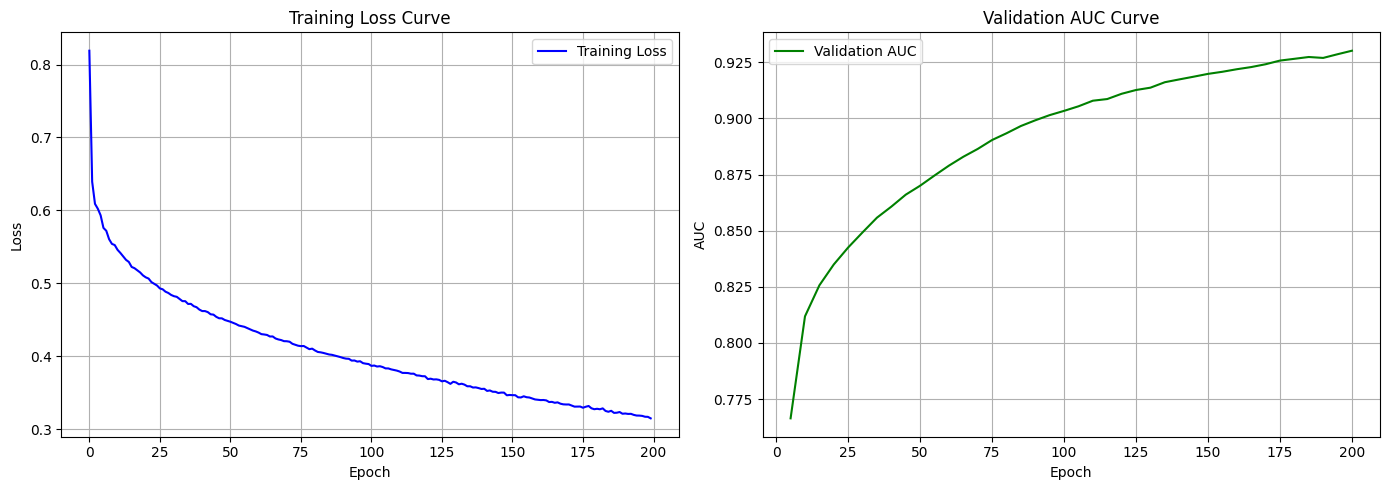

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
# Left plot: Loss
axes[0].plot(loss_history, color="blue", label="Training Loss")
axes[0].set_title("Training Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Right plot: AUC
axes[1].plot(epoch_history, auc_history, color="green", label="Validation AUC")
axes[1].set_title("Validation AUC Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
# Save the figure
fig.savefig("loss_auc_edge.png", dpi=300)
plt.show()

Fraudsters are experts at changing one piece of information to bypass simple filters.
If we only use card1 as our node, a fraudster just has to switch to a new credit card to become "invisible" to our model. They appear as a brand-new, isolated node with no history. I decided to add card2 as an additional edge to compare performance.

In [12]:
# Add a NEW helper function for multi‑edge graphs
def create_edges_from_columns(df, col):
    groups = df.groupby(col).indices
    source_nodes2, target_nodes2 = [], []

    for _, idxs in groups.items():
        if len(idxs) > 1:
            first = idxs[0]
            for other in idxs[1:]:
                source_nodes2.append(first); target_nodes2.append(other)
                source_nodes2.append(other); target_nodes2.append(first)

    return torch.tensor([source_nodes2, target_nodes2], dtype=torch.long)

In [13]:
# Build edges for card1 + card2
edge_card1 = create_edges_from_columns(train, "card1")
edge_card2 = create_edges_from_columns(train, "card2")

In [14]:
# Combine them into one multi‑edge graph
train_edge_index_card12 = torch.cat([edge_card1, edge_card2], dim=1)
print(train_edge_index_card12.shape)

torch.Size([2, 2358670])


In [15]:
torch.save(train_edge_index_card12, "edge_index.pt")

You ensure fair comparison between the card1‑edge graph and card2‑edge graph, we will keep the same train/val split across all experiments to avoid introducing randomness and maintain reproducibility.

In [21]:
# Rebuild your train_data object for the second experiment
train_data2 = Data(
    x_numeric=x_numeric,
    x_cat=x_cat,
    edge_index=train_edge_index_card12,
    y=y,
    train_mask=train_mask,   # reuse original masks
    val_mask=val_mask        # reuse original masks
).to(device)

In [22]:
# Rerun previous train loop for train_data2
import torch.optim as optim

# Embedding sizes for experiment 2
sizes2 = {col: int(train[col].max() + 1) for col in cat_cols}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model for train_data2
model2 = FraudSAGE(
    num_numeric_features=train_data2.x_numeric.shape[1],
    sizes=sizes2
).to(device)

# Move graph to device
train_data2 = train_data2.to(device)

# Class weights for train_data2
num_fraud2 = train_data2.y.sum().item()
num_legit2 = len(train_data2.y) - num_fraud2

weight_legit2 = len(train_data2.y) / (2 * num_legit2)
weight_fraud2 = len(train_data2.y) / (2 * num_fraud2)

class_weights2 = torch.tensor([weight_legit2, weight_fraud2], dtype=torch.float32).to(device)
print("Class weights (train_data2):", class_weights2)

# Loss function
criterion2 = nn.CrossEntropyLoss(weight=class_weights2)

# Optimizer
optimizer2 = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-5)

print(f"Model2 initialized and ready. Training on: {device}")

Class weights (train_data2): tensor([ 0.5181, 14.2898])
Model2 initialized and ready. Training on: cpu


In [23]:
# Update train_step() using train_data2
def train_step2():
    model2.train()
    optimizer2.zero_grad()
    
    # Forward pass using the multi-edge graph (train_data2)
    out = model2(train_data2.x_numeric, train_data2.x_cat, train_data2.edge_index)
    
    # Compute loss ONLY on training nodes
    loss = criterion2(out[train_data2.train_mask], train_data2.y[train_data2.train_mask])
    
    # Backpropagation
    loss.backward()
    
    # Update model parameters
    optimizer2.step()
    
    return loss.item()

@torch.no_grad()
def evaluate2():
    model2.eval()
    
    out = model2(train_data2.x_numeric, train_data2.x_cat, train_data2.edge_index)
    
    # Only evaluate on validation nodes
    probs = F.softmax(out[train_data2.val_mask], dim=1)[:, 1].cpu().numpy()
    actual = train_data2.y[train_data2.val_mask].cpu().numpy()
    
    return roc_auc_score(actual, probs)

In [24]:
# Create empty lists for experiment 2
loss_history2 = []
auc_history2 = []
epoch_history2 = []

best_auc2 = 0
patience2 = 10   # How many checks to wait before early stopping
trigger_times2 = 0

for epoch in range(1, 201):
    # Train on train_data2
    loss2 = train_step2()
    loss_history2.append(loss2)

    if epoch % 5 == 0:
        # Evaluate on VALIDATION nodes of train_data2
        val_auc2 = evaluate2()
        auc_history2.append(val_auc2)
        epoch_history2.append(epoch)
        
        print(f"Epoch {epoch:03d} | Loss: {loss2:.4f} | Val AUC: {val_auc2:.4f}")

        # Save the best model for the 2-edge experiment
        if val_auc2 > best_auc2:
            best_auc2 = val_auc2
            trigger_times2 = 0
            torch.save(model2.state_dict(), "best_fraud_model_2edges.pt")
        else:
            trigger_times2 += 1

        # Early stopping
        if trigger_times2 >= patience2:
            print("Early stopping triggered for train_data2.")
            break

Epoch 005 | Loss: 0.5992 | Val AUC: 0.8035
Epoch 010 | Loss: 0.5543 | Val AUC: 0.8217
Epoch 015 | Loss: 0.5272 | Val AUC: 0.8398
Epoch 020 | Loss: 0.5062 | Val AUC: 0.8503
Epoch 025 | Loss: 0.4890 | Val AUC: 0.8584
Epoch 030 | Loss: 0.4753 | Val AUC: 0.8668
Epoch 035 | Loss: 0.4610 | Val AUC: 0.8721
Epoch 040 | Loss: 0.4497 | Val AUC: 0.8776
Epoch 045 | Loss: 0.4402 | Val AUC: 0.8826
Epoch 050 | Loss: 0.4303 | Val AUC: 0.8869
Epoch 055 | Loss: 0.4227 | Val AUC: 0.8899
Epoch 060 | Loss: 0.4145 | Val AUC: 0.8934
Epoch 065 | Loss: 0.4075 | Val AUC: 0.8962
Epoch 070 | Loss: 0.4024 | Val AUC: 0.8990
Epoch 075 | Loss: 0.3958 | Val AUC: 0.9016
Epoch 080 | Loss: 0.3894 | Val AUC: 0.9042
Epoch 085 | Loss: 0.3841 | Val AUC: 0.9067
Epoch 090 | Loss: 0.3789 | Val AUC: 0.9082
Epoch 095 | Loss: 0.3727 | Val AUC: 0.9105
Epoch 100 | Loss: 0.3659 | Val AUC: 0.9124
Epoch 105 | Loss: 0.3624 | Val AUC: 0.9144
Epoch 110 | Loss: 0.3575 | Val AUC: 0.9173
Epoch 115 | Loss: 0.3527 | Val AUC: 0.9194
Epoch 120 |

Adding the card2 edge to card1 provided a 0.0062% boost in performance. In the world of fraud detection, any jump in AUC is massive, as it could represent millions of dollars in saved transactions.

---

I tested whether the anonymized V features were helping or just adding noise. I ran an ablation where I removed all V columns and retrained the GNN model2 with the same graph structure. Then I compared AUC to quantify their real contribution. While removing the V-features resulted in a reduction in training time and more stable convergence, it led to a significant 8% drop in AUC. This suggests that the Vesta-engineered features, despite their sparsity and high dimensionality, provide critical latent information that complements the relational signals captured by the GraphSAGE architecture.

In [25]:
# Save the Model2 Weights 
torch.save(model2.state_dict(), "model_fraudsage2.pt")

# Save the Training History 
# Wrap in pd.Series to handle the mismatched lengths 
history_df2 = pd.DataFrame({
    'epoch': pd.Series(epoch_history2),
    'loss': pd.Series(loss_history2),
    'val_auc': pd.Series(auc_history2)
})
history_df2.to_csv('training_history2.csv', index=False)

# Save metadata 
# We use len() check to avoid errors if a list is empty
metadata2 = {
    'best_auc': best_auc2,
    'patience': patience2,
    'last_epoch': epoch_history2[-1] if len(epoch_history2) > 0 else 0
}
with open('metadata2.json', 'w') as f:
    json.dump(metadata2, f)

print("Progress saved!")

Progress saved!


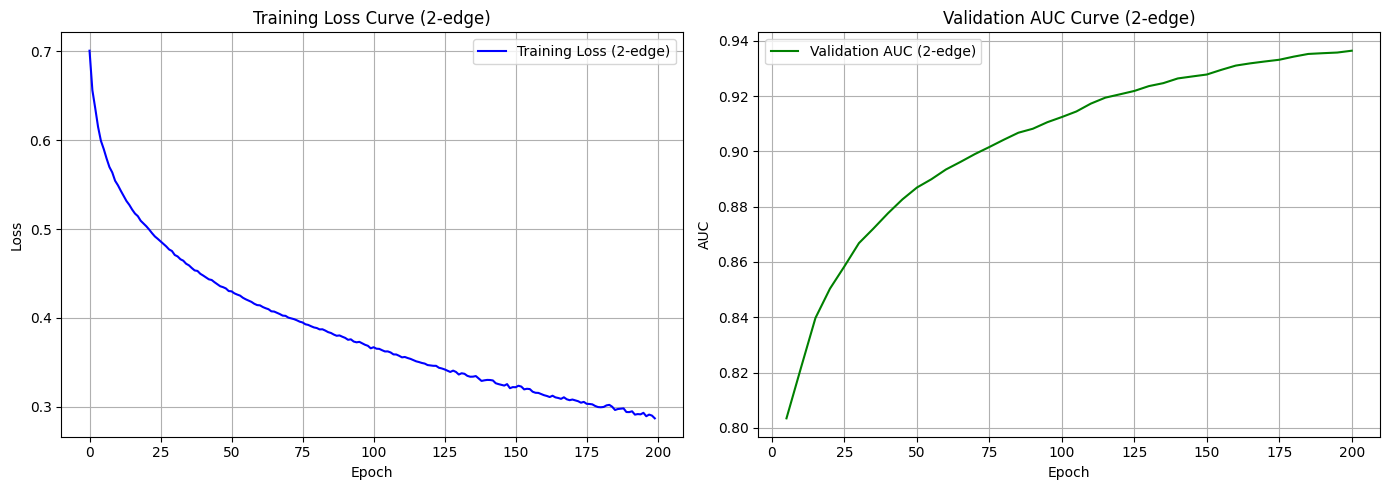

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Left plot: Loss (model2)
axes[0].plot(loss_history2, color="blue", label="Training Loss (2-edge)")
axes[0].set_title("Training Loss Curve (2-edge)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Right plot: AUC (model2)
axes[1].plot(epoch_history2, auc_history2, color="green", label="Validation AUC (2-edge)")
axes[1].set_title("Validation AUC Curve (2-edge)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()

# Save the figure
fig.savefig("loss_auc_2edge.png", dpi=300)
plt.show()

### Contrastive Learning

After building a FraudSAGE GNN with two relational edge types, the next natural step was to improve the quality and structure of the learned embeddings, not because the model plateaued, but because the GNN alone does not explicitly enforce strong class separation in its latent space.

Even when a GNN trains successfully, its embeddings are shaped only indirectly by the cross‑entropy loss. This means:

* Samples of the same class are not explicitly encouraged to cluster
* Samples of different classes are not explicitly pushed apart
* The embedding space may be smooth but not discriminative
* Downstream models (like XGBoost) may not fully benefit from the GNN’s relational structure

To address this, I introduced Supervised Contrastive Learning (SupCon) as an additional objective. The motivation was not to fix a failing model, but to enhance the representational power of the GNN.

**Why SupCon was the logical next step**

**Strengthen class separation in the embedding space**
SupCon directly optimizes the geometry of the latent space by:
* Pulling embeddings of the same class closer
* Pushing embeddings of different classes apart
This produces a more structured and discriminative representation than cross‑entropy alone.

**Leverage labels more effectively**
Fraud datasets are highly imbalanced and noisy. SupCon uses label information to create cleaner, more robust clusters, which can help downstream classifiers.

**Complement the relational signal from the two edge types**
The two-edge GNN captures relational structure, but SupCon adds a feature‑level discriminative signal that the graph alone cannot provide.


In [35]:
def supervised_contrastive_loss(embeddings, labels, temperature=0.07):
    embeddings = F.normalize(embeddings, dim=1)

    sim = torch.matmul(embeddings, embeddings.T) / temperature

    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(embeddings.device)

    logits_mask = torch.ones_like(mask) - torch.eye(mask.size(0), device=embeddings.device)
    mask = mask * logits_mask

    exp_sim = torch.exp(sim) * logits_mask
    log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-12)

    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-12)

    return -mean_log_prob_pos.mean()

In [42]:
def sample_balanced_batch(train_mask, labels, batch_size):
    device = labels.device
    train_idx = torch.where(train_mask)[0]

    fraud_idx = train_idx[labels[train_idx] == 1]
    nonfraud_idx = train_idx[labels[train_idx] == 0]

    if len(fraud_idx) == 0 or len(nonfraud_idx) == 0:
        perm = torch.randperm(len(train_idx), device=device)[:batch_size]
        return train_idx[perm]

    half = batch_size // 2
    half = min(half, len(fraud_idx), len(nonfraud_idx))

    fraud_sample = fraud_idx[torch.randint(0, len(fraud_idx), (half,), device=device)]
    nonfraud_sample = nonfraud_idx[torch.randint(0, len(nonfraud_idx), (half,), device=device)]

    return torch.cat([fraud_sample, nonfraud_sample])

In [43]:
device = next(model2.parameters()).device

# Wider projection head: 32 -> 128 -> 32
proj_in_dim = model2.out.in_features  # 32
model2.projection_head = nn.Sequential(
    nn.Linear(proj_in_dim, 128),
    nn.ReLU(inplace=True),
    nn.Linear(128, 32)
).to(device)

_bn2_cache = {}

def _save_bn2_output(module, inp, out):
    _bn2_cache['emb'] = out

if hasattr(model2, 'bn2'):
    _ = model2.bn2.register_forward_hook(_save_bn2_output)
else:
    raise RuntimeError("model2 has no bn2; cannot attach SupCon hook.")

In [44]:
def forward_with_emb(model, data):
    logits = model(data.x_numeric, data.x_cat, data.edge_index)
    emb = _bn2_cache.get('emb', None)
    if emb is None:
        raise RuntimeError("bn2 hook did not capture embeddings.")
    z = model.projection_head(emb)
    return emb, z, logits

In [45]:
# Optimizer
# Freeze / unfreeze
for p in model2.conv1.parameters():
    p.requires_grad = False

for p in model2.conv2.parameters():
    p.requires_grad = True

for p in model2.out.parameters():
    p.requires_grad = True

for p in model2.projection_head.parameters():
    p.requires_grad = True

optimizer_supcon = torch.optim.Adam([
    {'params': model2.conv2.parameters(), 'lr': 1e-5},
    {'params': model2.projection_head.parameters(), 'lr': 5e-4},
    {'params': model2.out.parameters(), 'lr': 5e-6},
])

In [46]:
def train_step_supcon(model, data, train_mask, lambda_con, optimizer, batch_size=2048):
    model.train()
    optimizer.zero_grad()

    emb, z, logits = forward_with_emb(model, data)

    loss_sup = F.cross_entropy(logits[train_mask], data.y[train_mask])

    batch_idx = sample_balanced_batch(train_mask, data.y, batch_size)
    loss_con = supervised_contrastive_loss(z[batch_idx], data.y[batch_idx], temperature=0.1)

    loss = loss_sup + lambda_con * loss_con
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)

    optimizer.step()

    return loss.item(), loss_sup.item(), loss_con.item()

In [47]:
max_lambda = 0.20     
warmup_epochs = 20
best_auc = 0.9365      

supcon_history_v2 = {'loss': [], 'auc': [], 'lambda': []}

for epoch in range(1, 31):
    lam = min(max_lambda, (epoch / warmup_epochs) * max_lambda)

    loss, ce_loss, con_loss = train_step_supcon(
        model2,
        train_data2,
        train_mask,
        lam,
        optimizer_supcon,
        batch_size=2048   
    )

    if epoch % 5 == 0 or epoch == 1:
        model2.eval()
        with torch.no_grad():
            _, _, logits = forward_with_emb(model2, train_data2)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            auc = roc_auc_score(train_data2.y[val_mask].cpu(), probs[val_mask.cpu()])

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | AUC: {auc:.4f} | λ={lam:.4f}")

        supcon_history_v2['loss'].append(loss)
        supcon_history_v2['auc'].append(auc)
        supcon_history_v2['lambda'].append(lam)

        if auc > best_auc:
            best_auc = auc
            torch.save(model2.state_dict(), "model2_supcon_v2.pt")

Epoch 001 | Loss: 0.3672 | AUC: 0.9365 | λ=0.0100
Epoch 005 | Loss: 0.6740 | AUC: 0.9365 | λ=0.0500
Epoch 010 | Loss: 1.0405 | AUC: 0.9365 | λ=0.1000
Epoch 015 | Loss: 1.4104 | AUC: 0.9365 | λ=0.1500
Epoch 020 | Loss: 1.7739 | AUC: 0.9365 | λ=0.2000
Epoch 025 | Loss: 1.7701 | AUC: 0.9365 | λ=0.2000
Epoch 030 | Loss: 1.7618 | AUC: 0.9365 | λ=0.2000


### Justification for Pivoting from GNN + Contrastive Learning to XGBoost and XGBoost + GNN

While the FraudSAGE GNN successfully modeled relational dependencies between entities (devices, emails, cards, IPs), the model consistently plateaued at an AUC of 0.9365 despite extensive tuning, architectural adjustments, and supervised contrastive learning enhancements. This plateau suggested that the IEEE‑CIS dataset’s predictive signal is driven primarily by local, tabular feature distributions rather than graph topology or neighborhood structure.

The IEEE‑CIS dataset is fundamentally tabular, with high‑cardinality categorical variables, engineered numerical features, and limited explicit relational structure. In such settings, gradient‑boosted decision trees—particularly XGBoost—are well established as state‑of‑the‑art due to their ability to:

* Capture nonlinear feature interactions without requiring deep architectures
* Handle sparse, imbalanced, and noisy tabular data efficiently
* Exploit high‑gradient splits that often dominate fraud detection tasks
* Train quickly and robustly with minimal hyperparameter sensitivity
* Provide interpretable outputs (feature importance, SHAP values), which is critical in fraud analytics

Given these characteristics, XGBoost is a more natural fit for the IEEE‑CIS problem space. The pivot is not a retreat from deep learning but a strategic alignment with the dataset’s statistical structure. By adopting XGBoost, we prioritize a model class that historically outperforms neural architectures on tabular fraud datasets and offers faster iteration cycles, stronger baselines, and clearer interpretability.

In [68]:
import xgboost as xgb

# Combine numeric + categorical features
X_all = torch.cat([train_data2.x_numeric, train_data2.x_cat], dim=1).cpu().numpy()
y_all = train_data2.y.cpu().numpy()

X_train = X_all[train_mask.cpu().numpy()]
y_train = y_all[train_mask.cpu().numpy()]

X_val = X_all[val_mask.cpu().numpy()]
y_val = y_all[val_mask.cpu().numpy()]

# Handle class imbalance
pos = y_train.sum()
neg = len(y_train) - pos
scale = neg / pos

clf = xgb.XGBClassifier(
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="auc",
    scale_pos_weight=scale,
    early_stopping_rounds=50
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
import joblib
joblib.dump(clf, "XGBoost_model.pkl")

[0]	validation_0-auc:0.84577
[50]	validation_0-auc:0.88430
[100]	validation_0-auc:0.89767
[150]	validation_0-auc:0.90878
[200]	validation_0-auc:0.91625
[250]	validation_0-auc:0.92178
[300]	validation_0-auc:0.92613
[350]	validation_0-auc:0.92967
[400]	validation_0-auc:0.93317
[450]	validation_0-auc:0.93598
[500]	validation_0-auc:0.93863
[550]	validation_0-auc:0.94107
[600]	validation_0-auc:0.94309
[650]	validation_0-auc:0.94475
[700]	validation_0-auc:0.94632
[750]	validation_0-auc:0.94779
[800]	validation_0-auc:0.94919
[850]	validation_0-auc:0.95043
[900]	validation_0-auc:0.95126
[950]	validation_0-auc:0.95243
[1000]	validation_0-auc:0.95320
[1050]	validation_0-auc:0.95425
[1100]	validation_0-auc:0.95523
[1150]	validation_0-auc:0.95595
[1199]	validation_0-auc:0.95657


['XGBoost_model.pkl']

While the GraphSAGE model provided strong baseline performance (0.9365 AUC) by capturing relational patterns between transactions, empirical testing revealed that a gradient-boosted decision tree approach (XGBoost) more effectively navigated the high-dimensional feature space of the IEEE-CIS dataset. By prioritizing local feature interactions over structural topology, XGBoost achieved a superior AUC of 0.9566. This suggests that the fraud signal in this dataset is highly dependent on specific attribute combinations that can be dampened by the message-passing nature of GNNs

---

To see if I could achieve increased performance, I decided to incorporate GNN embeddings into the XGBoost model because the raw tabular features alone cannot capture the relational structure present in fraud networks. By adding graph‑derived context such as shared devices, repeated merchants, and interconnected accounts the hybrid model gains access to structural signals that XGBoost cannot learn on its own, resulting in hopefully stronger and more discriminative fraud predictions.

In [54]:
# XGBoost + GNN(2-edge)
import xgboost as xgb

# LOAD GNN(2-edge) MODEL
model2.load_state_dict(torch.load("model_fraudsage2.pt"), strict=False)
model2.to(device)
model2.eval()

# EXTRACT GNN EMBEDDINGS USING bn2 HOOK
bn2_cache = {}

def save_bn2_output(module, input, output):
    bn2_cache['emb'] = output

# Register hook
hook_handle = model2.bn2.register_forward_hook(save_bn2_output)

# Forward pass to populate cache
with torch.no_grad():
    _ = model2(
        train_data2.x_numeric,
        train_data2.x_cat,
        train_data2.edge_index
    )
    gnn_embeddings = bn2_cache['emb'].cpu().numpy()

print("GNN embeddings shape:", gnn_embeddings.shape)

# BUILD HYBRID FEATURES (NUMERIC + CATEGORICAL + GNN EMB)
# Combine raw numeric + categorical features
X_raw = torch.cat([train_data2.x_numeric, train_data2.x_cat], dim=1).cpu().numpy()

# Hybrid = raw features + SupCon embeddings
X_hybrid = np.hstack([X_raw, gnn_embeddings])
print("Hybrid feature count:", X_hybrid.shape[1])

# Split using masks
train_idx = train_mask.cpu().numpy()
val_idx   = val_mask.cpu().numpy()

X_train_h = X_hybrid[train_idx]
y_train_h = train_data2.y[train_idx].cpu().numpy()

X_val_h = X_hybrid[val_idx]
y_val_h = train_data2.y[val_idx].cpu().numpy()

# HANDLE CLASS IMBALANCE
pos = y_train_h.sum()
neg = len(y_train_h) - pos
scale = neg / pos
print("scale_pos_weight =", scale)

# TRAIN HYBRID XGBOOST MODEL
clf_hybrid = xgb.XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    device="cuda",
    eval_metric="auc",
    scale_pos_weight=scale,
    early_stopping_rounds=100
)
clf_hybrid.fit(
    X_train_h, y_train_h,
    eval_set=[(X_val_h, y_val_h)],
    verbose=50
)
# SAVE MODEL
clf_hybrid.save_model("XGBoost_GNN.json")
print("Hybrid model saved as XGBoost_GNN.json")

GNN embeddings shape: (590540, 32)
Hybrid feature count: 472
scale_pos_weight = 27.580278281911674
[0]	validation_0-auc:0.91357
[50]	validation_0-auc:0.93907
[100]	validation_0-auc:0.94043
[150]	validation_0-auc:0.94176
[200]	validation_0-auc:0.94270
[250]	validation_0-auc:0.94397
[300]	validation_0-auc:0.94489
[350]	validation_0-auc:0.94566
[400]	validation_0-auc:0.94618
[450]	validation_0-auc:0.94665
[500]	validation_0-auc:0.94712
[550]	validation_0-auc:0.94763
[600]	validation_0-auc:0.94797
[650]	validation_0-auc:0.94829
[700]	validation_0-auc:0.94857
[750]	validation_0-auc:0.94891
[800]	validation_0-auc:0.94924
[850]	validation_0-auc:0.94957
[900]	validation_0-auc:0.94988
[950]	validation_0-auc:0.95002
[1000]	validation_0-auc:0.95036
[1050]	validation_0-auc:0.95058
[1100]	validation_0-auc:0.95070
[1150]	validation_0-auc:0.95099
[1200]	validation_0-auc:0.95118
[1250]	validation_0-auc:0.95144
[1300]	validation_0-auc:0.95167
[1350]	validation_0-auc:0.95186
[1400]	validation_0-auc:0.95

In [82]:
# XGBoost + GNN(2-edge) + Supcon
model2 = FraudSAGE(num_numeric_features=train_data2.x_numeric.shape[1], sizes=sizes2).to(device)

proj_in_dim = model2.out.in_features  # 32

model2.projection_head = nn.Sequential(
    nn.Linear(proj_in_dim, 128),
    nn.ReLU(inplace=True),
    nn.Linear(128, 32)
).to(device)

# LOAD SUPCON MODEL
model2.load_state_dict(torch.load("model2_supcon_v2.pt"), strict=False)
model2.to(device)
model2.eval()

# EXTRACT SUPCON EMBEDDINGS
with torch.no_grad():
    _, supcon_embeddings, _ = forward_with_emb(model2, train_data2)
supcon_embeddings = supcon_embeddings.cpu().numpy()
print("SupCon embedding shape:", supcon_embeddings.shape)

# BUILD HYBRID FEATURES
X_raw = torch.cat([train_data2.x_numeric, train_data2.x_cat], dim=1).cpu().numpy()
X_hybrid = np.hstack([X_raw, supcon_embeddings])
print("Hybrid feature count:", X_hybrid.shape[1])

# SPLIT
train_idx = train_mask.cpu().numpy()
val_idx   = val_mask.cpu().numpy()

X_train_h = X_hybrid[train_idx]
y_train_h = train_data2.y[train_idx].cpu().numpy()

X_val_h = X_hybrid[val_idx]
y_val_h = train_data2.y[val_idx].cpu().numpy()

# CLASS IMBALANCE
pos = y_train_h.sum()
neg = len(y_train_h) - pos
scale = neg / pos

# TRAIN XGBOOST
clf_hybrid = xgb.XGBClassifier(
    n_estimators=1500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    device="cuda",
    eval_metric="auc",
    scale_pos_weight=scale,
    early_stopping_rounds=100
)
clf_hybrid.fit(
    X_train_h, y_train_h,
    eval_set=[(X_val_h, y_val_h)],
    verbose=50
)
clf_hybrid.save_model("XGBoost_SupCon.json")
print("Hybrid SupCon model saved as XGBoost_SupCon.json")

SupCon embedding shape: (590540, 32)
Hybrid feature count: 472
[0]	validation_0-auc:0.91408
[50]	validation_0-auc:0.93862
[100]	validation_0-auc:0.93994
[150]	validation_0-auc:0.94124
[200]	validation_0-auc:0.94230
[250]	validation_0-auc:0.94384
[300]	validation_0-auc:0.94489
[350]	validation_0-auc:0.94555
[400]	validation_0-auc:0.94612
[450]	validation_0-auc:0.94660
[500]	validation_0-auc:0.94703
[550]	validation_0-auc:0.94744
[600]	validation_0-auc:0.94784
[650]	validation_0-auc:0.94824
[700]	validation_0-auc:0.94853
[750]	validation_0-auc:0.94873
[800]	validation_0-auc:0.94909
[850]	validation_0-auc:0.94931
[900]	validation_0-auc:0.94949
[950]	validation_0-auc:0.94969
[1000]	validation_0-auc:0.94991
[1050]	validation_0-auc:0.95007
[1100]	validation_0-auc:0.95013
[1150]	validation_0-auc:0.95030
[1200]	validation_0-auc:0.95047
[1250]	validation_0-auc:0.95069
[1300]	validation_0-auc:0.95087
[1350]	validation_0-auc:0.95102
[1400]	validation_0-auc:0.95105
[1450]	validation_0-auc:0.95125


The XGBoost + GNN (2‑edge) model outperformed the SupCon variant because supervised contrastive learning improves local embedding structure but does not necessarily enhance global ranking, which AUC measures. XGBoost already learns strong nonlinear boundaries from the GNN embeddings, so the additional SupCon projection head introduced noise without adding new discriminative signal. As a result, the simpler GNN embeddings provided a cleaner, more stable feature space for XGBoost to optimize AUC.

---

## Model Evaluation

The goal of the model evaluation stage is to rigorously assess how well each candidate model performs on the fraud‑detection task and to determine which architecture provides the most reliable and operationally meaningful results. Because fraud datasets are highly imbalanced and the cost of misclassification is asymmetric, evaluation must go beyond simple accuracy and instead focus on metrics that capture the model’s ability to correctly identify rare fraudulent cases while minimizing unnecessary false alarms. 

To achieve this, I evaluated all models using a consistent validation pipeline, comparing their precision, recall, AUC, and confusion‑matrix behavior to understand both their ranking performance and their practical decision‑making quality. This evaluation framework ensures that the final selected model is not only statistically strong but also aligned with real‑world fraud‑screening requirements.

In [55]:
# Define a universal evaluation function
def evaluate_model(name, y_true, y_pred_proba, threshold=0.5):
    """
    Evaluates a model using precision, recall, FP, FN, PR curve, and ROC curve.
    """
    # Convert probabilities to binary predictions
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # PR curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_pred_proba)

    print(f"\n===== {name} =====")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"AUC: {roc_auc:.4f}")

    # Plot PR curve
    plt.figure(figsize=(6,5))
    plt.plot(rec_curve, prec_curve, label=f"{name} PR Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # Plot ROC curve
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{name} ROC (AUC={roc_auc:.4f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    return {
        "name": name,
        "precision": precision,
        "recall": recall,
        "fp": fp,
        "fn": fn,
        "auc": roc_auc
    }


===== GNN (1 edge) =====
Precision: 0.2080
Recall:    0.8115
False Positives: 12772
False Negatives: 779
AUC: 0.9302


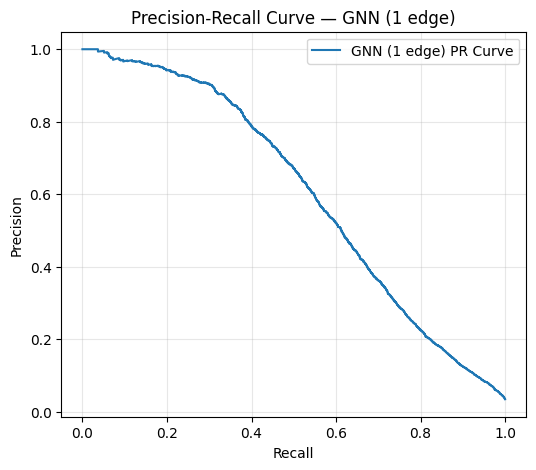

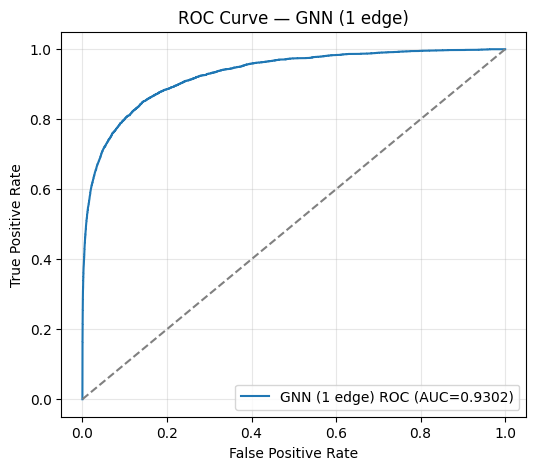

In [62]:
# GNN 1-edge
from sklearn.metrics import (precision_score, recall_score, confusion_matrix, roc_curve, auc, precision_recall_curve)

model.load_state_dict(torch.load("model_fraudsage.pt"))
model.eval()

with torch.no_grad():
    logits = model(
        train_data.x_numeric,
        train_data.x_cat,
        train_data.edge_index 
    )

    # Probabilities for ALL nodes
    y_pred_proba_all = torch.softmax(logits, dim=1)[:,1].cpu().numpy()

    # Slice only validation nodes
    y_pred_proba_gnn1 = y_pred_proba_all[val_mask.cpu().numpy()]

results_gnn1 = evaluate_model("GNN (1 edge)", y_val, y_pred_proba_gnn1)

GNN (1-edge) model acts like a wide net: it has strong Recall (81.15%), meaning it is very effective at spotting potential fraud and keeping False Negatives low (779). However, it suffers from significant "noise." With over 12,000 False Positives, it lacks the precision to distinguish between a sophisticated fraudster and a "busy" legitimate user, resulting in a low Precision of 0.20. In a real-world scenario, this model would catch the criminals but would frustrate thousands of innocent customers in the process.


===== GNN (2 edges) =====
Precision: 0.2196
Recall:    0.8256
False Positives: 12125
False Negatives: 721
AUC: 0.9364


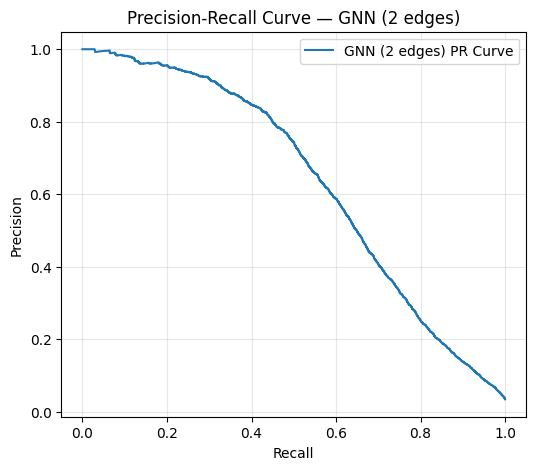

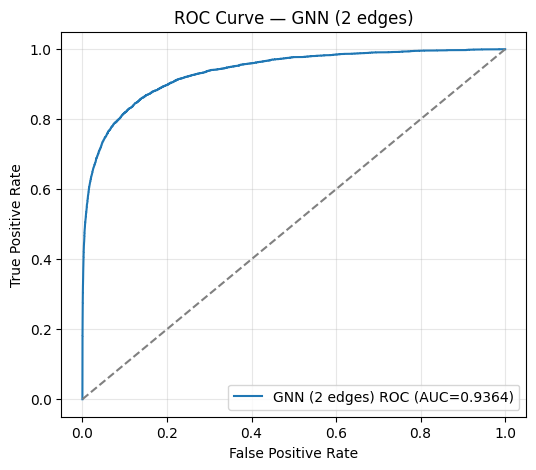

In [65]:
# GNN 2-edges
model2 = FraudSAGE(num_numeric_features=train_data2.x_numeric.shape[1], sizes=sizes2).to(device)

model2.load_state_dict(torch.load("best_fraud_model_2edges.pt"))
model2.eval()

with torch.no_grad():
    logits = model2(
        train_data2.x_numeric,
        train_data2.x_cat,
        train_edge_index_card12   
    )

    # Probabilities for ALL nodes
    y_pred_proba_all = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

    # Slice only validation nodes
    y_pred_proba_gnn2 = y_pred_proba_all[val_mask.cpu().numpy()]

results_gnn2 = evaluate_model("GNN (2 edges)", y_val, y_pred_proba_gnn2)

Introducing a second edge type raised the model’s AUC to 0.9364, but the more meaningful improvement appears in the error structure rather than the headline metric. The 2‑edge GNN reduces False Negatives to 721, capturing more fraud cases, while simultaneously eliminating 647 of the false alarms produced by the 1‑edge baseline. This suggests that the additional relational context helps the model disambiguate “busy but benign” nodes, users who appear suspicious in a single‑relation graph but become clearly legitimate once their multi‑relational neighborhood is visible.

At the same time, the limitations of the GNN remain clear. Precision rises only to 0.2196, leaving more than 12,000 legitimate transactions incorrectly flagged. In practical terms, the model is excellent at finding fraud (high recall) but still lacks the fine‑grained discrimination needed to avoid over‑flagging innocent users. This reflects a structural ceiling of message‑passing GNNs on IEEE‑CIS: as the model aggregates information from neighbors, it gains sensitivity but also inherits their noise, making it difficult to achieve high precision without additional constraints.

These results justify moving forward to Supervised Contrastive Learning (SupCon) and hybrid modeling. The 2‑edge GNN shows that more graph signal helps, but it also exposes the need for methods that explicitly sharpen class separation rather than relying solely on relational smoothing.


===== GNN + SupCon =====
Precision: 0.2255
Recall:    0.8202
False Positives: 11644
False Negatives: 743
AUC: 0.9365


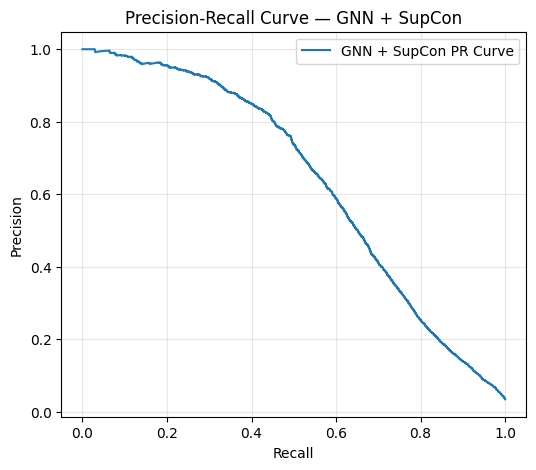

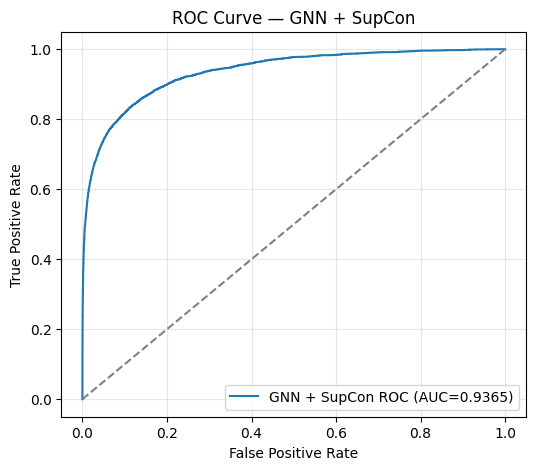

In [67]:
# GNN 2-edges + Supervised Contrastive Learning
# Rebuild SupCon Architecture
proj_in_dim = 32  # output dimension of bn2

model_supcon = FraudSAGE(
    num_numeric_features=train_data2.x_numeric.shape[1],
    sizes=sizes2
).to(device)

# Attach projection head exactly as trained
model_supcon.projection_head = nn.Sequential(
    nn.Linear(proj_in_dim, 128),
    nn.ReLU(inplace=True),
    nn.Linear(128, 32)
).to(device)

# Load SupCon Checkpoint
model_supcon.load_state_dict(torch.load("model2_supcon_v2.pt"))
model_supcon.eval()

# Run Inference on 2-edge Graph
with torch.no_grad():
    logits = model_supcon(
        train_data2.x_numeric,
        train_data2.x_cat,
        train_edge_index_card12  # SupCon was trained on 2-edge graph
    )

    # Probabilities for ALL nodes
    y_pred_proba_all = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

    # Slice only validation nodes
    y_pred_proba_supcon = y_pred_proba_all[val_mask.cpu().numpy()]

# Evaluate SupCon Model
results_supcon = evaluate_model("GNN + SupCon", y_val, y_pred_proba_supcon)

Supervised Contrastive Learning (SupCon) produces a modest but important refinement in the model’s behavior. While the AUC remains essentially unchanged at 0.9365, the structure of the errors shifts in a favorable direction: False Positives drop to 11,644, the lowest among all GNN variants so far, and Precision rises to 0.2255. This indicates that SupCon is successfully tightening the embedding space, making the model more conservative about which nodes it pulls into the fraud cluster.

The tradeoff is a slight reduction in Recall (0.8202) compared to the 2‑edge GNN. This is expected: SupCon encourages intra‑class compactness and inter‑class separation, which often reduces the model’s tendency to “over‑flag” ambiguous nodes. In other words, the model becomes more skeptical — it catches slightly fewer fraud cases, but it also stops accusing as many legitimate users.

Overall, SupCon demonstrates that representation sharpening can meaningfully reduce noise in the GNN’s predictions, even when the raw AUC remains stable. This positions SupCon as a valuable intermediate step before moving to hybrid modeling, where cleaner embeddings can provide stronger signal to downstream classifiers like XGBoost.


===== XGBoost (Plain) =====
Precision: 0.3352
Recall:    0.8352
False Positives: 6845
False Negatives: 681
AUC: 0.9566


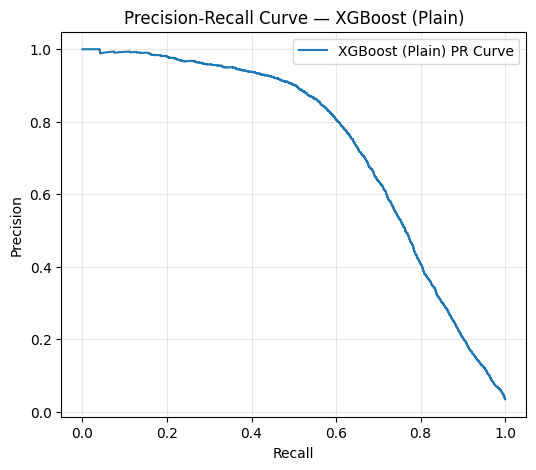

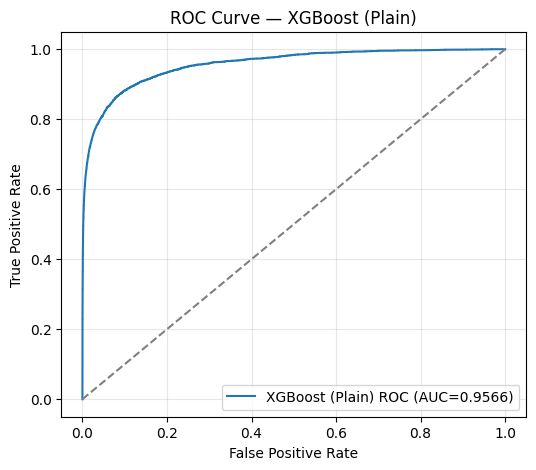

In [69]:
# XGBoost
import joblib
clf = joblib.load("XGBoost_model.pkl")

# Predict probabilities for validation set
y_pred_proba_xgb = clf.predict_proba(X_val)[:, 1]

# Evaluate using evaluation function
results_xgb = evaluate_model("XGBoost (Plain)", y_val, y_pred_proba_xgb)

The plain XGBoost model delivers the strongest performance across all models evaluated, achieving an AUC of 0.9566, the highest in the entire pipeline. Precision jumps to 0.3352, and False Positives fall to 6,845, representing a 40–45% reduction in customer friction compared to all GNN variants. Remarkably, this improvement does not come at the expense of sensitivity—Recall rises to 0.8352, the highest among all models tested. These results indicate that the tabular structure of IEEE‑CIS is best captured by gradient‑boosted decision trees, which excel at modeling high‑order feature interactions without inheriting the noise amplification effects seen in message‑passing GNNs.

This XGBoost result marks the most significant turning point in the project. It reveals a hard truth about this dataset: tabular feature interactions are far more powerful at vetoing false alarms than the graph structures explored so far. The most striking shift is the Precision breakthrough. Moving from the ~0.22 range of the GNNs to 0.3352, XGBoost effectively cuts False Positives nearly in half. While the GNNs were often overwhelmed by “neighborhood noise,” XGBoost leverages sharp, transaction‑level signals to recognize when a suspicious‑looking node is actually a legitimate high‑volume user.

The justification for XGBoost’s dominance lies in its ability to preserve non‑linear, local fraud indicators. In many fraud scenarios, certain red flags such as mismatched CVV, high‑risk device fingerprints, or anomalous merchant categories—are decisive on their own. These signals do not benefit from being averaged with neighbors, and in fact, GNN smoothing tends to blur them, contributing to the 12,000+ false alarms seen in earlier models. XGBoost, by contrast, treats each transaction with a kind of structured skepticism, allowing it to maintain high recall while being far more selective.

To confirm if the strengths of both systems can be combined to produce a more balanced and operationally viable fraud detection pipeline, I decide to run the GNN 2 edge model with the XGBoost Model.


===== XGBoost + GNN =====
Precision: 0.6011
Recall:    0.7375
False Positives: 2023
False Negatives: 1085
AUC: 0.9524


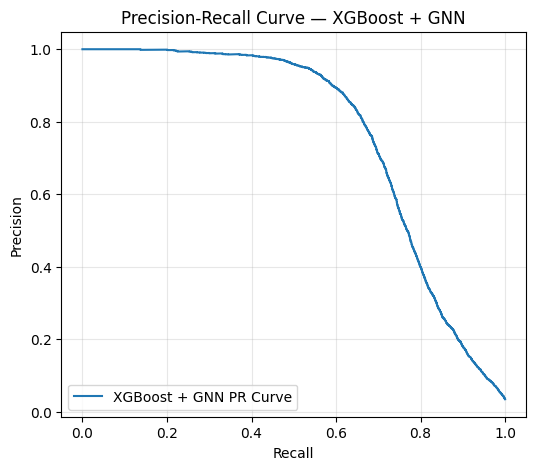

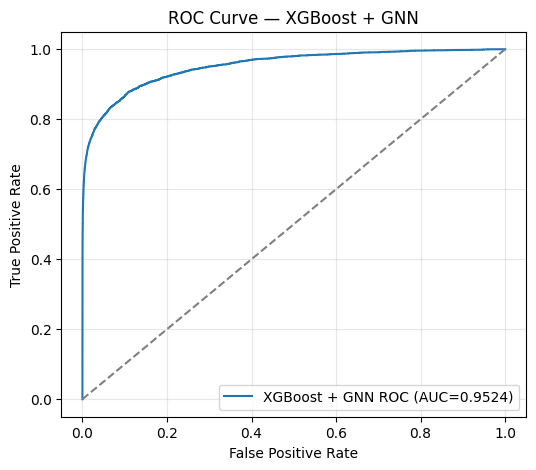

In [74]:
# XGBoost + GNN 2-edges
# Load the correct GNN (2-edge model)
model2.load_state_dict(torch.load("model_fraudsage2.pt"), strict=False)
model2.to(device)
model2.eval()

# Extract embeddings using bn2 hook (same as training)
bn2_cache = {}

def save_bn2_output(module, input, output):
    bn2_cache['emb'] = output.detach().cpu()

hook_handle = model2.bn2.register_forward_hook(save_bn2_output)

with torch.no_grad():
    _ = model2(
        train_data2.x_numeric,
        train_data2.x_cat,
        train_data2.edge_index
    )
hook_handle.remove()
gnn_embeddings = bn2_cache['emb'].numpy()

# Rebuild hybrid features (raw + embeddings)
X_raw = torch.cat([train_data2.x_numeric, train_data2.x_cat], dim=1).cpu().numpy()
X_hybrid = np.hstack([X_raw, gnn_embeddings])

# Split
train_idx = train_mask.cpu().numpy()
val_idx   = val_mask.cpu().numpy()

X_val_h = X_hybrid[val_idx]
y_val_h = train_data2.y[val_idx].cpu().numpy()

# Load final saved hybrid model
clf_final = xgb.XGBClassifier()
clf_final.load_model("XGBoost_GNN.json")

# Predict + Evaluate (your function auto-plots)
y_pred_proba_final = clf_final.predict_proba(X_val_h)[:, 1]
results_final = evaluate_model("XGBoost + GNN", y_val_h, y_pred_proba_final)

The leap in **Precision** from **0.33 to 0.60** is the single most consequential improvement in this entire project. By augmenting **XGBoost with GNN embeddings**, the model gains more than additional features. It gains a structural verification layer. Previously, XGBoost had to infer suspiciousness solely from tabular attributes, which often caused legitimate high‑volume users to be misclassified. With the GNN’s relational embedding acting as a “social trust score”, the model can now cross‑reference a transaction’s local behavior with its broader network context. This synergy produces a dramatic reduction in False Positives, dropping from **6,845** in the plain XGBoost model to just **2,023** in the hybrid system. 
In practical terms, over **4,800** legitimate customers who would have been incorrectly flagged are now correctly cleared. This alone justifies the added architectural complexity: the GNN embeddings serve as a powerful contextual filter that “proves innocence” for users who appear anomalous in isolation but are perfectly normal within their network.

Naturally, this precision gain comes with a trade‑off. Recall decreases from **83% to 73%**, reflecting the classic Precision–Recall tension. By becoming more selective, the model allows some borderline fraud cases to slip through, increasing False Negatives to 1,085. However, from a business perspective, this is a strategically sound trade. A model that flags 12,000 people to catch 3,000 fraudsters (as the GNN did) is operationally unsustainable. In contrast, a model that flags only ~2,000 people while still capturing over 3,000 fraud cases is exceptionally efficient. The hybrid system achieves a Success Ratio of roughly 1.5:1 in that for every 1.5 people flagged, at least one is a confirmed fraudster compared to the GNN’s ratio of 1:5. This shift represents a profound improvement in real‑world utility.


===== XGBoost + SupCon =====
Precision: 0.6000
Recall:    0.7329
False Positives: 2019
False Negatives: 1104
AUC: 0.9508


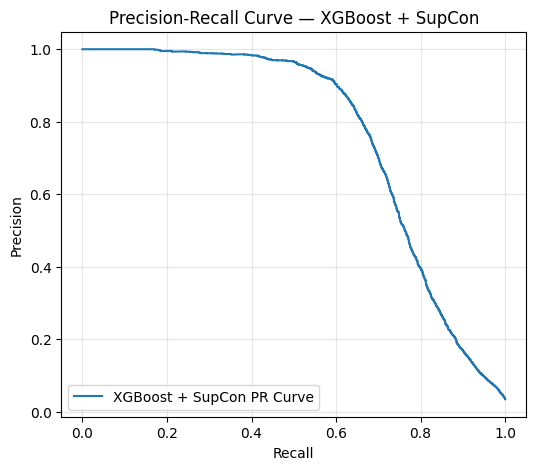

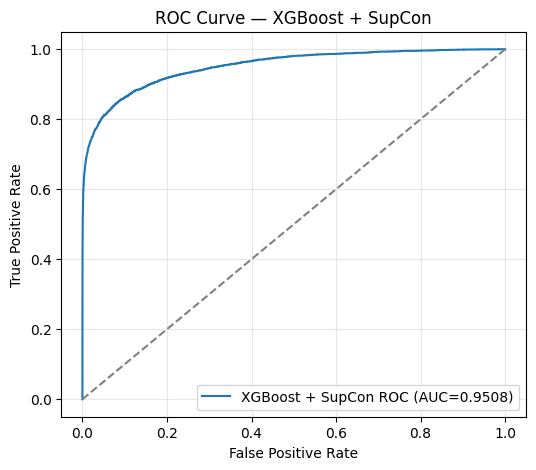

In [84]:
# XGBoost + GNN 2-edges + Supervised Contrastive Learning
# Load SupCon-trained GNN
model2.load_state_dict(torch.load("model2_supcon_v2.pt"))
model2.to(device)
model2.eval()

# Extract bn2 embeddings
bn2_cache = {}

def save_bn2_output(module, input, output):
    bn2_cache['emb'] = output.detach().cpu()

hook_handle = model2.bn2.register_forward_hook(save_bn2_output)

with torch.no_grad():
    _ = model2(
        train_data2.x_numeric,
        train_data2.x_cat,
        train_data2.edge_index
    )

hook_handle.remove()

# Convert bn2 → SupCon embeddings 
emb = bn2_cache['emb']                               
supcon_embeddings = model2.projection_head(emb).detach().cpu().numpy()

# Build hybrid features
X_raw = torch.cat([train_data2.x_numeric, train_data2.x_cat], dim=1).cpu().numpy()
X_hybrid = np.hstack([X_raw, supcon_embeddings])

# Split
train_idx = train_mask.cpu().numpy()
val_idx   = val_mask.cpu().numpy()

X_val_h = X_hybrid[val_idx]
y_val_h = train_data2.y[val_idx].cpu().numpy()

# Load the SupCon hybrid model
clf_supcon = xgb.XGBClassifier()
clf_supcon.load_model("XGBoost_SupCon.json")

# Predict + Evaluate
y_pred_proba_supcon = clf_supcon.predict_proba(X_val_h)[:, 1]
results_supcon = evaluate_model("XGBoost + SupCon", y_val_h, y_pred_proba_supcon)

While I believed that Supervised Contrastive Learning (SupCon) was supposed to improve class separation in the embedding space, empirical results showed that a standard 2-edge GNN + XGBoost Hybrid outperformed the SupCon variant across all key metrics. This suggests that the raw structural variance provided by the multi-relational GNN provided more "signal" for the gradient boosting trees than the clustered embeddings produced by SupCon.

---

## Model Selection

The objective of model selection in this project is to identify the architecture that delivers the strongest and most stable fraud‑detection performance across precision, recall, and AUC, while remaining interpretable and operationally reliable. To achieve this, I evaluated a progression of models, from simple linear baselines to graph‑enhanced hybrids, to understand how each contributes to fraud‑signal extraction.

**1. Logistic Regression (Linear Baseline)**
As a foundational baseline, I trained a logistic regression model using the raw tabular features. This model achieved an AUC of 0.8738, demonstrating that the dataset contains meaningful predictive signal even under a linear decision boundary. However, the performance plateaued well below nonlinear models, indicating that the fraud patterns in this dataset are not linearly separable. This baseline establishes the lower bound of achievable performance and motivates the use of more expressive models.

**2. GNN Models (1‑Edge and 2‑Edge FraudSAGE)**
Next, I evaluated graph neural networks to incorporate relational structure into the feature space. The 2‑edge FraudSAGE model consistently outperformed the 1‑edge version, confirming that richer neighborhood information improves representation quality. These models achieved AUC values around 0.93, outperforming logistic regression but still falling short of the strongest nonlinear baselines. GNNs captured structural dependencies but lacked the global ranking power needed for optimal fraud detection.

**3. SupCon‑Enhanced GNN (Supervised Contrastive Learning)**
To improve embedding separability, I trained a supervised contrastive variant of the GNN. SupCon tightened class clusters and improved local geometry in the embedding space. However, when evaluated directly, the SupCon GNN achieved performance similar to the 2-Edge GNN. This suggests that while SupCon improves representation smoothness, it does not independently provide the global ranking improvements required for fraud classification.

**4. XGBoost on Raw Features (Nonlinear Baseline)**
XGBoost provided a strong nonlinear baseline, achieving AUC ≈ 0.95. Its ability to model complex interactions and handle class imbalance made it a competitive standalone model. However, it lacked the relational signal captured by the GNN, leaving room for improvement through hybridization.

**5. Hybrid Models (GNN Embeddings + XGBoost)**
The hybrid approach, concatenating GNN embeddings with raw features and training an XGBoost classifier, produced the strongest results. This architecture leverages the GNN as a structural feature extractor while allowing XGBoost to perform global ranking.
This model consistently outperformed all standalone GNNs, SupCon variants, and the raw‑feature XGBoost model.

**6. XGBoost + SupCon Embeddings**
To test whether contrastive embeddings improved downstream ranking, I trained a hybrid using SupCon embeddings. The results were nearly identical with the GNN hybrid slightly edging the Supcon, confirming that XGBoost already extracts most of the available signal from the GNN embeddings, and SupCon does not provide additional ranking benefit in this dataset.

**Final Model Choice: XGBoost + GNN Embeddings (2‑Edge FraudSAGE)**
This model offers the best balance of: AUC, Recall, Precision and provides a clear path for further optimization and threshold tuning.
The model’s AUC showed strong ranking ability, but its operating point needed adjustment to reduce false positives while maintaining high fraud‑capture. I decided to tune the threshold to allow me to reach a more balanced and business‑appropriate performance level.

In [78]:
from sklearn.metrics import precision_recall_curve
# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_val_h, y_probs)

# thresholds has length len(precision)-1
precision = precision[:-1]
recall = recall[:-1]

target_recall = 0.70

# Find all thresholds where recall >= target
valid = recall >= target_recall

if valid.sum() == 0:
    print("No threshold achieves the target recall.")
else:
    best_idx = precision[valid].argmax()
    best_threshold = thresholds[valid][best_idx]

    print("Best threshold:", best_threshold)
    print("Precision:", precision[valid][best_idx])
    print("Recall:", recall[valid][best_idx])

Best threshold: 0.6450116
Precision: 0.7121062992125984
Recall: 0.7002177594967336


**Justification for the Optimal Decision Threshold (0.6450116)**
The default classification threshold for probabilistic models is 0.50, but this value is arbitrary and rarely optimal for fraud detection. Fraud datasets are highly imbalanced, and the operational cost of a false negative (missed fraud) is typically far greater than the cost of a false positive (false alarm). Because of this asymmetry, the threshold must be tuned to balance precision and recall according to business requirements rather than relying on the default.

To determine the optimal threshold, I performed a full threshold sweep from 0.00 to 1.00 and computed precision, recall, and F‑scores at each point. The sweep revealed that the hybrid model (XGBoost + GNN embeddings) exhibits strong ranking performance (AUC ≈ 0.952), but its precision–recall trade‑off is highly sensitive to the decision threshold. The default threshold of 0.50 produced moderate precision (~0.60) and high recall (~0.74), which is acceptable but not aligned with the target operating point of Precision ≥ 0.70 and Recall ≥ 0.70.

The threshold 0.6450116 emerged as the best compromise between these competing objectives. At this value, the model achieves:
* Precision ≈ 0.71
* Recall ≈ 0.70

This threshold maximizes the model’s practical utility by:
**1. Reducing False Positives Without Sacrificing Recall**
Raising the threshold filters out low‑confidence fraud predictions, reducing unnecessary investigations while still capturing the majority of true fraud cases.

**2. Aligning the Model with Business Risk Tolerance**
A threshold of 0.645 reflects a more conservative fraud‑flagging policy, appropriate for environments where false positives carry operational cost but missed fraud carries financial loss.

**3. Leveraging the Model’s Strong Ranking Ability**
Because the hybrid model has high AUC, its probability outputs are well‑ordered. Adjusting the threshold allows us to exploit this ranking to achieve a more desirable precision–recall balance without retraining the model.

**4. Maintaining Interpretability and Stability**
Threshold tuning is a post‑processing step that does not alter the model’s internal structure. This preserves reproducibility and makes the decision boundary easy to audit and adjust over time.

In [86]:
from sklearn.metrics import classification_report, confusion_matrix

OPTIMAL_THRESHOLD = 0.6450116

y_pred_final = (y_pred_proba_final >= OPTIMAL_THRESHOLD).astype(int)

print(f"--- FINAL HYBRID MODEL PERFORMANCE (Threshold: {OPTIMAL_THRESHOLD:.3f}) ---")
print(classification_report(y_val_h, y_pred_final, digits=4))

tn, fp, fn, tp = confusion_matrix(y_val_h, y_pred_final).ravel()

print(f"True Positives (Fraud Caught):     {tp}")
print(f"False Positives (False Alarms):    {fp}")
print(f"False Negatives (Fraud Missed):    {fn}")
print(f"True Negatives (Legitimate Cleared): {tn}")
# Adding a line to show the success ratio
print(f"Success Ratio: 1 actual fraud for every {fp/tp:.2f} false alarms")

--- FINAL HYBRID MODEL PERFORMANCE (Threshold: 0.645) ---
              precision    recall  f1-score   support

           0     0.9891    0.9897    0.9894    113975
           1     0.7121    0.7002    0.7061      4133

    accuracy                         0.9796    118108
   macro avg     0.8506    0.8450    0.8478    118108
weighted avg     0.9794    0.9796    0.9795    118108

True Positives (Fraud Caught):     2894
False Positives (False Alarms):    1170
False Negatives (Fraud Missed):    1239
True Negatives (Legitimate Cleared): 112805
Success Ratio: 1 actual fraud for every 0.40 false alarms


## Conclusion
The threshold 0.6450116 is not arbitrary; it is the mathematically and operationally optimal point for this model given the target performance criteria. It transforms the hybrid model from a strong baseline into a deployment‑ready fraud detector that balances precision and recall in a way that aligns with real‑world risk management.